# Task 2: Sentiment Classification on Yelp Polarity

This notebook trains three models from scratch (baseline, BiLSTM, BiLSTM with attention). The config name is read from the `CONFIG` environment variable (`local` or `gpu`).

## 1. Setup

In [1]:
import json
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml
from sklearn.metrics import accuracy_score, f1_score

sys.path.append("src")
sys.path.append("..")
import eval_task2
from data import ROOT, clean_text, get_data, load_config, load_test_raw
from models import build_model, count_parameters
from utils import (Logger, get_device, load_checkpoint, make_scheduler, peak_memory_mb,
                   reset_peak_memory, save_checkpoint)

config_name = os.environ.get("CONFIG", "local")
cfg = load_config(config_name)

random.seed(cfg["seed"])
np.random.seed(cfg["seed"])
torch.manual_seed(cfg["seed"])

device, device_name = get_device()

out_dir = ROOT / cfg["paths"]["output_dir"]
out_dir.mkdir(parents=True, exist_ok=True)
print("config:", config_name)
print("device:", device_name)

C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config: gpu
device: NVIDIA GeForce RTX 4090


## 2. Load Data

In [2]:
train_loader, val_loader, test_loader, word_to_idx, info = get_data(cfg)
print("train reviews:", info["counts"]["train"])
print("val reviews:  ", info["counts"]["val"])
print("test reviews: ", info["counts"]["test"])

train reviews: 190000
val reviews:   10000
test reviews:  38000


## 3. Exploring the Data

### Class balance

       negative  positive  positive share
train     95120     94880           0.499
val        5016      4984           0.498
test      19000     19000           0.500


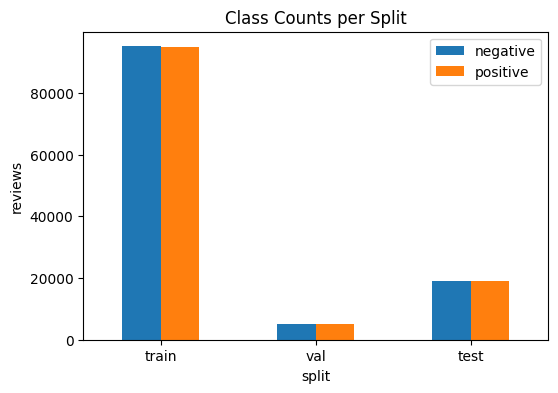

In [3]:
balance = pd.DataFrame(info["class_counts"]).T
balance["positive share"] = (balance["positive"] / (balance["positive"] + balance["negative"])).round(3)
print(balance)

balance[["negative", "positive"]].plot(kind="bar", figsize=(6, 4), rot=0)
plt.title("Class Counts per Split")
plt.xlabel("split")
plt.ylabel("reviews")
plt.savefig(out_dir / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

### Missing, broken or escaped rows

In [4]:
malformed = pd.DataFrame(info["dropped"]).T[["total", "not_text", "empty", "bad_label", "kept", "escaped", "unicode_escaped"]]
print(malformed)
print("escaped = reviews with written-out escapes such as \\u00fc or \\n (decoded, not dropped)")
print("empty after cleaning:", info["empty_after_cleaning"])

              total  not_text  empty  bad_label    kept  escaped  \
train_split  560000         0      0          0  560000   302789   
test_split    38000         0      0          0   38000    20464   

             unicode_escaped  
train_split            12521  
test_split               879  


escaped = reviews with written-out escapes such as \u00fc or \n (decoded, not dropped)
empty after cleaning: {'train': 15, 'val': 0, 'test': 0}


### Review length

words per review: 50th = 98, 90th = 283, 95th = 373


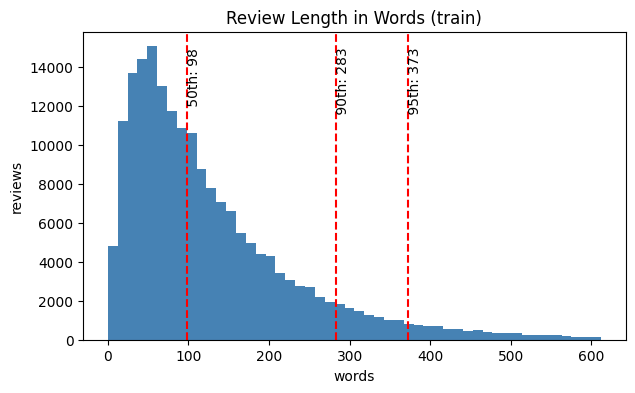

In [5]:
arrays = np.load(ROOT / cfg["paths"]["processed_dir"] / "arrays.npz")
words = arrays["train_words"]
p50, p90, p95 = np.percentile(words, [50, 90, 95])
print(f"words per review: 50th = {p50:.0f}, 90th = {p90:.0f}, 95th = {p95:.0f}")

plt.figure(figsize=(7, 4))
plt.hist(words, bins=50, range=(0, np.percentile(words, 99)), color="steelblue")
for value, name in [(p50, "50th"), (p90, "90th"), (p95, "95th")]:
    plt.axvline(value, color="red", linestyle="--")
    plt.text(value, plt.ylim()[1] * 0.95, f" {name}: {value:.0f}", rotation=90, va="top")
plt.title("Review Length in Words (train)")
plt.xlabel("words")
plt.ylabel("reviews")
plt.savefig(out_dir / "length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Cleaning and Tokenizing

### Before and after cleaning

In [6]:
raw = load_test_raw(cfg)
for i in range(3):
    text = raw["text"].iloc[i]
    print(f"review {i + 1} (label {raw['label'].iloc[i]})")
    print("before:", text[:400])
    print("after: ", clean_text(text)[:400])
    print()

review 1 (label 1)
before: I enjoy coming to this location because it is never super busy and the customer service is great. The staff is very friendly and the food is terrific  Since the temperatures are semi-dropping, I do like that they have an outdoor patio because it's great to enjoy the evening weather... The bathrooms are always clean
after:  enjoy come locat never super busi custom servic great staff friendli food terrif sinc temperatur semi drop like outdoor patio great enjoy even weather bathroom alway clean

review 2 (label 1)
before: I've been to the Bell Centre five times in my life for Canadians games. All five times I left in awe!!! The place is HUGE with a 21,000 capacity for sporting events, and I'd guess an additional 3,000 for concerts.   The air inside for hockey is electric! Location is prime too. You can get to high quality hotels, Casino de Montreal, delicious restaurants, fun pubs, and great shops all within walkin
after:  bell centr five time life canadian game

### Vocab and max length

In [7]:
print("vocab size:", info["vocab_size"])
print("max length:", info["max_len"])
for name, share in info["cut_share"].items():
    print(f"{name}: {share * 100:.1f}% of reviews are cut at max length")

vocab size: 30000
max length: 256
train: 2.0% of reviews are cut at max length
val: 1.9% of reviews are cut at max length
test: 2.0% of reviews are cut at max length


### Most common words

In [8]:
print(list(word_to_idx)[2:32])

['not', 'place', 'food', 'good', 'like', 'get', 'go', 'time', 'one', 'order', 'would', 'servic', 'great', 'back', 'no', 'realli', 'tri', 'even', 'us', 'look', 'want', 'could', 'got', 'come', 'wait', 'also', 'restaur', 'ask', 'make', 'love']


## 5. Training the Models

### Settings and validation

In [9]:
tcfg = cfg["train"]
model_names = ["baseline", "bilstm", "bilstm_attn"]
vocab_size = len(word_to_idx)
loss_fn = nn.BCEWithLogitsLoss()


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum, count = 0.0, 0
    preds, labels = [], []
    for ids, lengths, y in loader:
        ids, lengths, y = ids.to(device), lengths.to(device), y.to(device)
        logits = model(ids, lengths)
        loss_sum += loss_fn(logits, y.float()).item() * len(y)
        count += len(y)
        preds.append((logits > 0).long().cpu())
        labels.append(y.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    model.train()
    return loss_sum / count, accuracy_score(labels, preds), f1_score(labels, preds, average="macro")

### Training function

In [10]:
def train_model(name):
    run_dir = out_dir / name
    ckpt_dir = ROOT / cfg["paths"]["checkpoint_dir"] / name
    if (run_dir / "summary.json").exists():
        print(f"{name}: already finished, skipping")
        return
    run_dir.mkdir(parents=True, exist_ok=True)
    logger = Logger(run_dir / "train_log.txt")

    torch.manual_seed(cfg["seed"])
    mcfg = cfg["models"][name]
    model = build_model(name, cfg, vocab_size).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=mcfg["lr"], weight_decay=tcfg["weight_decay"])
    total_steps = tcfg["epochs"] * len(train_loader)
    scheduler = make_scheduler(optimizer, int(tcfg["warmup_ratio"] * total_steps), total_steps)

    logger.log(f"model: {name}")
    logger.log(f"device: {device_name}")
    logger.log(f"torch version: {torch.__version__}")
    logger.log("config:\n" + yaml.dump({"model": mcfg, "train": tcfg}, sort_keys=False))
    logger.log(f"parameters: {count_parameters(model)}")

    last_path, best_path = ckpt_dir / "last.pt", ckpt_dir / "best.pt"
    start_epoch, step, best_f1, bad_epochs = 0, 0, -1.0, 0
    history = []
    if last_path.exists():
        ckpt = load_checkpoint(last_path, model, optimizer, scheduler, device)
        start_epoch, step = ckpt["epoch"], ckpt["step"]
        best_f1, bad_epochs = ckpt["best_f1"], ckpt["bad_epochs"]
        history = pd.read_csv(run_dir / "history.csv").iloc[:start_epoch].to_dict("records")
        logger.log(f"resumed from last.pt at epoch {start_epoch}, step {step}")

    reset_peak_memory(device)
    model.train()
    for epoch in range(start_epoch, tcfg["epochs"]):
        if bad_epochs >= tcfg["patience"]:
            break
        torch.manual_seed(cfg["seed"] + epoch)
        epoch_start = time.time()
        interval_start = time.time()
        interval_loss, interval_n, interval_examples = 0.0, 0, 0
        epoch_loss, epoch_n, nan_count = 0.0, 0, 0

        for ids, lengths, y in train_loader:
            ids, lengths, y = ids.to(device), lengths.to(device), y.float().to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(ids, lengths), y)
            if not torch.isfinite(loss):
                nan_count += 1
                continue
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg["grad_clip"]).item()
            optimizer.step()
            scheduler.step()
            step += 1

            interval_loss += loss.item()
            interval_n += 1
            interval_examples += len(y)
            epoch_loss += loss.item()
            epoch_n += 1

            if step % tcfg["log_every"] == 0:
                speed = interval_examples / (time.time() - interval_start)
                logger.log(f"step {step} | train loss {interval_loss / interval_n:.4f} | "
                           f"lr {scheduler.get_last_lr()[0]:.6f} | grad norm {grad_norm:.3f} | "
                           f"examples/sec {speed:.0f}")
                interval_start = time.time()
                interval_loss, interval_n, interval_examples = 0.0, 0, 0

        train_time = time.time() - epoch_start
        train_loss = epoch_loss / epoch_n
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)
        epoch_time = time.time() - epoch_start
        mem = peak_memory_mb(device)
        logger.log(f"epoch {epoch + 1}/{tcfg['epochs']} | train loss {train_loss:.4f} | "
                   f"val loss {val_loss:.4f} | val acc {val_acc:.4f} | val macro-F1 {val_f1:.4f} | "
                   f"time {epoch_time:.1f}s | nan losses {nan_count}")

        history.append({"epoch": epoch + 1, "step": step, "train_loss": train_loss,
                        "val_loss": val_loss, "val_acc": val_acc, "val_macro_f1": val_f1,
                        "train_time": train_time, "epoch_time": epoch_time, "nan_losses": nan_count,
                        "peak_memory_mb": mem if mem is not None else float("nan")})
        pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)

        if val_f1 > best_f1:
            best_f1, bad_epochs = val_f1, 0
            save_checkpoint(best_path, model, optimizer, scheduler, epoch + 1, step, best_f1, bad_epochs, cfg)
        else:
            bad_epochs += 1
        save_checkpoint(last_path, model, optimizer, scheduler, epoch + 1, step, best_f1, bad_epochs, cfg)
        if bad_epochs >= tcfg["patience"]:
            logger.log(f"early stopping: val macro-F1 did not improve for {tcfg['patience']} epochs")

    h = pd.DataFrame(history)
    peak = h["peak_memory_mb"].max()
    summary = {
        "model": name,
        "device": device_name,
        "parameters": count_parameters(model),
        "epochs_run": len(h),
        "stopped_early": bad_epochs >= tcfg["patience"],
        "best_epoch": int(h.loc[h["val_macro_f1"].idxmax(), "epoch"]),
        "best_val_macro_f1": float(best_f1),
        "total_training_time_s": float(h["epoch_time"].sum()),
        "examples_per_sec": float(len(train_loader.dataset) * len(h) / h["train_time"].sum()),
        "peak_memory_mb": None if pd.isna(peak) else float(peak),
        "nan_losses": int(h["nan_losses"].sum()),
    }
    with open(run_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    logger.log(f"finished {name}, best val macro-F1 {best_f1:.4f}")

### Train all three models

In [11]:
for name in model_names:
    train_model(name)

summaries = []
for name in model_names:
    with open(out_dir / name / "summary.json") as f:
        summaries.append(json.load(f))
pd.DataFrame(summaries).set_index("model")

model: baseline
device: NVIDIA GeForce RTX 4090
torch version: 2.14.1+cu132
config:
model:
  embed_dim: 128
  dropout: 0.2
  lr: 0.002
train:
  epochs: 5
  batch_size: 256
  patience: 2
  weight_decay: 0.01
  grad_clip: 1.0
  warmup_ratio: 0.1
  log_every: 100

parameters: 3840129


step 100 | train loss 0.6893 | lr 0.000544 | grad norm 0.118 | examples/sec 50095


step 200 | train loss 0.6368 | lr 0.001084 | grad norm 0.112 | examples/sec 112532


step 300 | train loss 0.4937 | lr 0.001623 | grad norm 0.077 | examples/sec 113833


step 400 | train loss 0.3461 | lr 0.001983 | grad norm 0.076 | examples/sec 114537


...

step 3500 | train loss 0.0712 | lr 0.000064 | grad norm 0.263 | examples/sec 2562


step 3600 | train loss 0.0674 | lr 0.000034 | grad norm 0.416 | examples/sec 2563


step 3700 | train loss 0.0684 | lr 0.000004 | grad norm 0.385 | examples/sec 2556


epoch 5/5 | train loss 0.0703 | val loss 0.1698 | val acc 0.9422 | val macro-F1 0.9422 | time 75.6s | nan losses 0
finished bilstm_attn, best val macro-F1 0.9434


,device,parameters,epochs_run,stopped_early,best_epoch,best_val_macro_f1,total_training_time_s,examples_per_sec,peak_memory_mb,nan_losses
model,,,,,,,,,,
baseline,NVIDIA GeForce RTX 4090,3840129,5,False,4,0.927895,9.457437,103107.221953,139.510254,0
bilstm,NVIDIA GeForce RTX 4090,4104449,5,False,5,0.938894,147.503433,6569.913874,364.170898,0
bilstm_attn,NVIDIA GeForce RTX 4090,4499970,5,False,4,0.943396,380.222530,2533.409796,520.448242,0


## 6. Training Curves

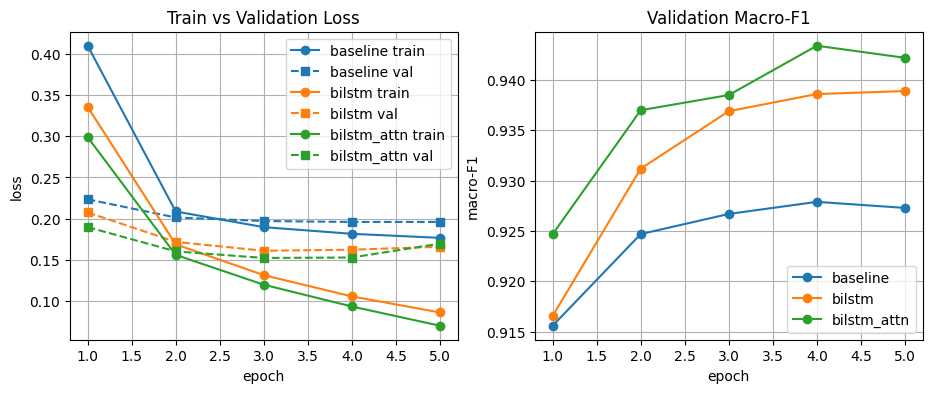

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in model_names:
    h = pd.read_csv(out_dir / name / "history.csv")
    line, = axes[0].plot(h["epoch"], h["train_loss"], marker="o", label=f"{name} train")
    axes[0].plot(h["epoch"], h["val_loss"], marker="s", linestyle="--", color=line.get_color(), label=f"{name} val")
    axes[1].plot(h["epoch"], h["val_macro_f1"], marker="o", label=name)
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("macro-F1")
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.savefig(out_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Evaluation on the Test Set

### Predict on the test set

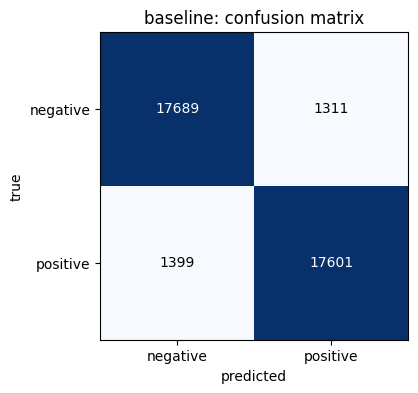

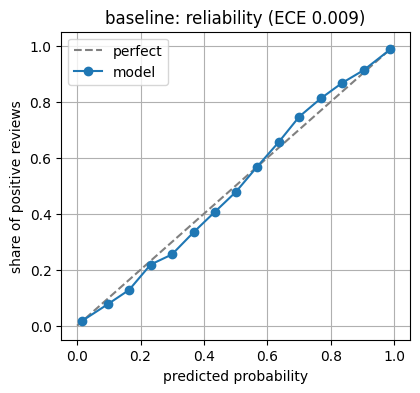

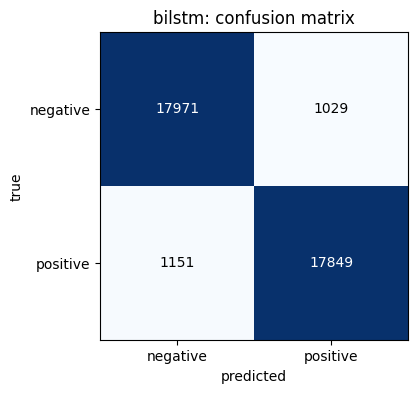

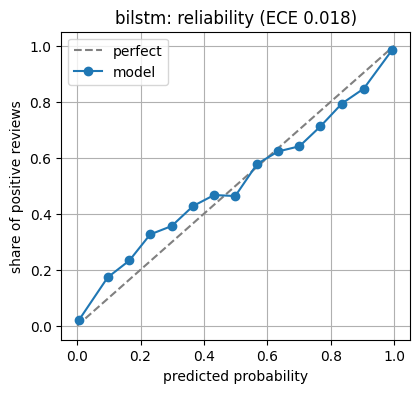

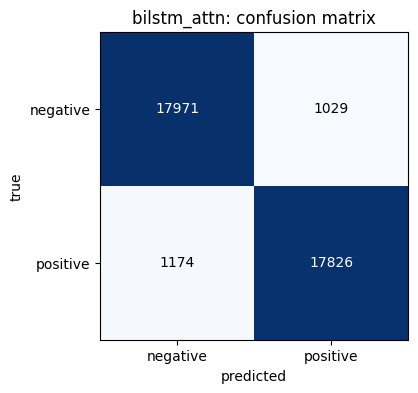

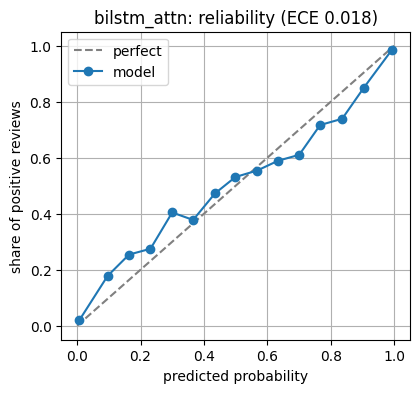

In [13]:
raw = load_test_raw(cfg)
y_test = raw["label"].to_numpy()
assert np.array_equal(y_test, arrays["test_y"])
slices = eval_task2.make_slices(raw["text"], raw["raw_words"])


@torch.no_grad()
def predict(name):
    model = build_model(name, cfg, vocab_size).to(device)
    ckpt = torch.load(ROOT / cfg["paths"]["checkpoint_dir"] / name / "best.pt", map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    model.eval()
    probs = []
    for ids, lengths, y in test_loader:
        logits = model(ids.to(device), lengths.to(device))
        probs.append(torch.sigmoid(logits).cpu())
    return torch.cat(probs).numpy()


probs, preds = {}, {}
for name in model_names:
    probs[name] = predict(name)
    preds[name] = (probs[name] >= 0.5).astype(int)
    run_dir = out_dir / name
    table = pd.DataFrame({"id": raw["orig_index"], "label": y_test, "prob": probs[name],
                          "pred": preds[name], "word_count": raw["raw_words"], **slices})
    table.to_csv(run_dir / "predictions.csv", index=False)
    cm = eval_task2.get_confusion_matrix(y_test, preds[name])
    eval_task2.plot_confusion_matrix(cm, run_dir / "confusion_matrix.png", f"{name}: confusion matrix")
    eval_task2.plot_reliability(y_test, probs[name], run_dir / "reliability.png", f"{name}: reliability")
    plt.show()

### Metrics report

In [14]:
rows = []
for name in model_names:
    row = {"model": name}
    row.update(eval_task2.evaluate_all(y_test, probs[name], preds[name], slices))
    if name != "baseline":
        test = eval_task2.mcnemar_exact(y_test, preds["baseline"], preds[name])
        row["mcnemar_vs_baseline_b"] = test["b"]
        row["mcnemar_vs_baseline_c"] = test["c"]
        row["mcnemar_vs_baseline_p"] = test["p_value"]
    with open(out_dir / name / "summary.json") as f:
        summary = json.load(f)
    row["parameters"] = summary["parameters"]
    row["training_time_s"] = summary["total_training_time_s"]
    row["examples_per_sec"] = summary["examples_per_sec"]
    row["peak_memory_mb"] = summary["peak_memory_mb"]
    row["device"] = summary["device"]
    rows.append(row)

report = pd.DataFrame(rows)
report.to_csv(out_dir / "metrics_report.csv", index=False)
print("saved", report.shape[0], "rows x", report.shape[1], "columns")

saved 3 rows x 49 columns


## 8. Comparing My Models

In [15]:
main_columns = ["accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc", "brier", "ece",
                "parameters", "training_time_s", "examples_per_sec"]
report.set_index("model")[main_columns].round(4)

,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier,ece,parameters,training_time_s,examples_per_sec
model,,,,,,,,,,
baseline,0.9287,0.9287,0.9771,0.9770,0.8574,0.0540,0.0087,3840129,9.4574,103107.2220
bilstm,0.9426,0.9426,0.9862,0.9867,0.8853,0.0437,0.0184,4104449,147.5034,6569.9139
bilstm_attn,0.9420,0.9420,0.9866,0.9870,0.8841,0.0439,0.0184,4499970,380.2225,2533.4098


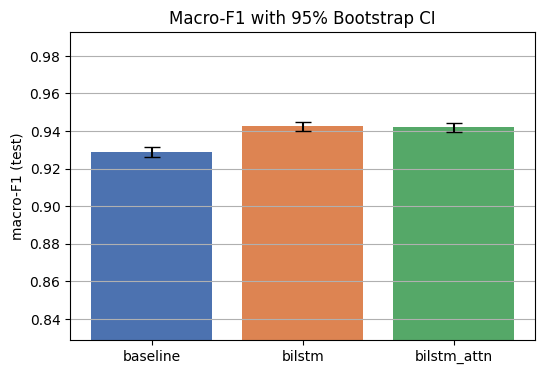

In [16]:
f1 = report["f1_macro"]
errors = [f1 - report["f1_macro_ci_low"], report["f1_macro_ci_high"] - f1]

plt.figure(figsize=(6, 4))
plt.bar(report["model"], f1, yerr=errors, capsize=6, color=["#4c72b0", "#dd8452", "#55a868"])
plt.ylim(max(0, f1.min() - 0.1), min(1, f1.max() + 0.05))
plt.ylabel("macro-F1 (test)")
plt.title("Macro-F1 with 95% Bootstrap CI")
plt.grid(True, axis="y")
plt.savefig(out_dir / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Error Review

### Pick the errors

In [17]:
attn_name = "bilstm_attn"
attn_model = build_model(attn_name, cfg, vocab_size).to(device)
ckpt = torch.load(ROOT / cfg["paths"]["checkpoint_dir"] / attn_name / "best.pt", map_location=device, weights_only=False)
attn_model.load_state_dict(ckpt["model"])
attn_model.eval()

idx_to_word = {i: w for w, i in word_to_idx.items()}
test_x, test_len = arrays["test_x"], arrays["test_len"]

df = pd.DataFrame({"id": raw["orig_index"], "text": raw["text"], "label": y_test,
                   "prob": probs[attn_name], "pred": preds[attn_name]})
wrong = df["pred"] != df["label"]

slice_names = list(slices)
attn_row = report[report["model"] == attn_name].iloc[0]
worst_slice = min(slice_names, key=lambda s: attn_row[f"{s}_f1_macro"])
print("worst slice for", attn_name, "->", worst_slice, f"(macro-F1 {attn_row[worst_slice + '_f1_macro']:.3f})")


def take(frame, count, used):
    frame = frame[~frame.index.isin(used)].head(count)
    used.update(frame.index)
    return frame


used = set()
false_pos = take(df[df["label"] == 0].sort_values("prob", ascending=False), 5, used)
false_neg = take(df[df["label"] == 1].sort_values("prob"), 5, used)
near = take(df[wrong].assign(gap=(df["prob"] - 0.5).abs()).sort_values("gap"), 5, used)
slice_errors = take(df[wrong & slices[worst_slice]].sample(frac=1, random_state=cfg["seed"]), 5, used)

worst slice for

 bilstm_attn -> short (macro-F1 0.936)


### Attention words and the review table

In [18]:
@torch.no_grad()
def top_attention(row, k=5):
    ids = torch.tensor(test_x[row].astype(np.int64))[None].to(device)
    length = torch.tensor([int(test_len[row])]).to(device)
    _, weights = attn_model(ids, length, return_attention=True)
    weights = weights[0, :int(length)].cpu()
    top = torch.topk(weights, min(k, len(weights)))
    return ", ".join(f"{idx_to_word[int(ids[0, p])]} ({w:.2f})"
                     for w, p in zip(top.values.tolist(), top.indices.tolist()))


def shorten(text, limit=300):
    text = " ".join(text.split())
    return text if len(text) <= limit else text[:limit] + "..."


groups = [("confident false positive", false_pos, False),
          ("confident false negative", false_neg, False),
          ("near-threshold error", near, True),
          (f"slice error ({worst_slice})", slice_errors, True)]

rows = []
for category, frame, show_attention in groups:
    for i, r in frame.iterrows():
        rows.append({
            "category": category,
            "id": r["id"],
            "review": shorten(r["text"]),
            "label": r["label"],
            "prob": round(r["prob"], 3),
            "slice": ", ".join(s for s in slice_names if slices[s][i]),
            "top_attention_words": top_attention(i) if show_attention else "",
            "error_type": "",
        })

review_table = pd.DataFrame(rows)
review_table.to_csv(out_dir / "error_review.csv", index=False)
print("saved", len(review_table), "reviews to error_review.csv")
review_table.style.hide(axis="index").set_properties(
    subset=["review", "top_attention_words"], **{"text-align": "left", "white-space": "pre-wrap"})

saved 20 reviews to error_review.csv


category,id,review,label,prob,slice,top_attention_words,error_type
confident false positive,29330,"Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012",0,1.000000,short,,
confident false positive,9565,"Not a very fun place to stay. The place is inexpensive and feels that way, as well. It's a great room if you're just planning to sleep there, and nothing else. It's a place to hold your stuff as you enjoy the rest of your vacation. The shows at the LVH are a hit or miss. Raiding the Rock Vault was r...",0,0.999000,"medium, has_negation",,
confident false positive,408,"Though I'm a Copper enthusiast when it comes to getting my Indian fix in Charlotte, I'd heard that Maharani was a cheaper but tasty option, so we ordered from there a few nights ago. Copper is definitely still my place, but Maharani was fine enough. First of all, the food came very quickly, which is...",0,0.999000,"medium, has_negation, has_contrast",,
confident false positive,18122,"20 years for me and sad to see them go. Sadder still to see a great traditional Japanese sushi restaurant end, and not carry on the tradition. We would go here for consistently great fresh fish and great service. They have also trained many young sushi chefs through the years here in Phoenix. Great ...",0,0.999000,"medium, has_negation, has_contrast",,
confident false positive,4488,It's good. The rolls are better than the sashimi although one time we had some really nice(and surprising) maguro. We always get the hamachi jalapeño roll and some sashimi so don't get me wrong when I say the rolls are better than the sashimi. It's still enjoyable. Good atmosphere and my girl likes ...,0,0.999000,"medium, has_negation, has_contrast",,
confident false negative,16148,"The employees at this Target seemed unusually friendly during my last visit. Two of them asked if they could help me find anything, the cashier was perky and personable, and the security guard offered to put my shopping cart back for me as I was walking out with my bags. Maybe I've gotten too used t...",1,0.001000,"medium, has_negation, has_contrast",,
confident false negative,22807,"EDIT: They really did change the service up since I last posted this. Horrible service. Used to be my favorite pizza in the city (at a reasonable price), but I'm rethinking that. We just had an altercation with a server who refused to split a check when we were paying with cash. He then proceeded to...",1,0.001000,"medium, has_negation, has_contrast",,
confident false negative,19078,"I was so looking forward our dinner here. I took my husband here for his 30th birthday and I waited for this day like a kid that's ready to meet Mickey & Co. Few hours prior to our dinner, I ended up having the worst stomach ache and I couldn't even try anything, other then a bite of caviar(YUMMO), ...",1,0.001000,"medium, has_negation",,
confident false negative,30793,"This place is so much better since they changed owners. My wife and I went when it was the old owners, it was terrible. We waited forever and the food never came before we walked out. People were served before us that walked in after and my wife actually got her soup before me and I sat and waited w...",1,0.001000,"medium, has_negation, has_contrast",,
confident false negative,11808,"It was Anniversary time! But we didn't' want to spend a ton of money on food or booze. Plus, were weren't interested in going to a show at the time. So, what to do? Aquarium! Don't get me wrong: This place is TINY! Narrow walk ways and close quarters in general. Even the exhibits are small. I do hop...",1,0.001000,"long, has_negation, has_contrast",,
